# Практика: Наивный Байес с нуля и сравнение со `scikit-learn`

## Что вы сделаете
В этом ноутбуке вы:

1. загрузите и изучите датасет для задачи классификации;
2. подготовите данные для обучения;
3. реализуете **Гауссовский Наивный Байес с нуля**:
   - оценку априорных вероятностей классов,
   - оценку параметров (среднее и дисперсия) по каждому признаку,
   - вычисление правдоподобия (likelihood),
   - классификацию по правилу Байеса;
4. обучите свою модель;
5. сравните её качество и параметры с реализацией из `scikit-learn`;
6. проверите, что происходит при нарушении допущения о независимости признаков.

## Важно
- Сначала дописывайте пропуски в **своей** реализации.
- Только после этого переходите к сравнению со `scikit-learn`.
- Не удаляйте проверки и комментарии: они помогают вам понять ход решения.

## Датасет
Мы используем `Iris` из `sklearn.datasets`:
- задача **многоклассовой классификации** (3 класса);
- признаки числовые, непрерывные;
- датасет хорошо подходит для изучения Гауссовского Наивного Байеса.

## Что сдавать
1. Заполненный ноутбук.
2. Краткие выводы в конце:
   - насколько близки метрики вашей модели и `scikit-learn`;
   - в чём главное допущение Наивного Байеса и когда оно нарушается;
   - когда Наивный Байес предпочтительнее логистической регрессии.

## Коротко о теории

### 1. Теорема Байеса
Для классификации нам нужно найти наиболее вероятный класс \(c\) при данных признаках \(x\):

\[
P(c \mid x) = \frac{P(x \mid c) \cdot P(c)}{P(x)}
\]

Так как \(P(x)\) одинаково для всех классов, достаточно максимизировать числитель:

\[
\hat{c} = \arg\max_{c} \; P(x \mid c) \cdot P(c)
\]

### 2. Наивное допущение о независимости
«Наивным» Байес называется потому, что предполагает условную **независимость** признаков:

\[
P(x \mid c) = \prod_{j=1}^{d} P(x_j \mid c)
\]

Это сильное допущение, которое редко выполняется на практике, но модель всё равно часто работает хорошо.

### 3. Гауссовское допущение
Для непрерывных признаков предполагаем, что каждый признак имеет нормальное распределение внутри класса:

\[
P(x_j \mid c) = \frac{1}{\sqrt{2\pi\sigma_{cj}^2}} \exp\!\left(-\frac{(x_j - \mu_{cj})^2}{2\sigma_{cj}^2}\right)
\]

### 4. Логарифм для численной стабильности
Произведение многих вероятностей быстро стремится к нулю. На практике считаем **логарифм**:

\[
\log P(c \mid x) \propto \log P(c) + \sum_{j=1}^{d} \log P(x_j \mid c)
\]

### 5. Что будем сравнивать
После своей реализации вы сравните результат с `sklearn.naive_bayes.GaussianNB`:
- accuracy,
- precision (macro),
- recall (macro),
- f1 (macro).

### 6. Априорные вероятности
Оцениваются по частоте встречаемости каждого класса в обучающей выборке:

\[
P(c) = \frac{n_c}{n}
\]

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)




In [55]:
import matplotlib.pyplot as plt
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=['#FFB6C1', '#FFC0CB', '#FFDAB9', '#FFE4B5', '#FF69B4'])

In [56]:
data = load_iris()

X = pd.DataFrame(data.data, columns = data.feature_names)
y = pd.Series(data.target, name = "target")

print("Размер X:", X.shape)
print("Классы:", data.target_names)
display(X.head())
display(y.value_counts().rename(index = dict(enumerate(data.target_names))))

Размер X: (150, 4)
Классы: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


target
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Пропуски по признакам:


sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64


Базовая статистика:


,count,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal width (cm),150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal length (cm),150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal width (cm),150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5


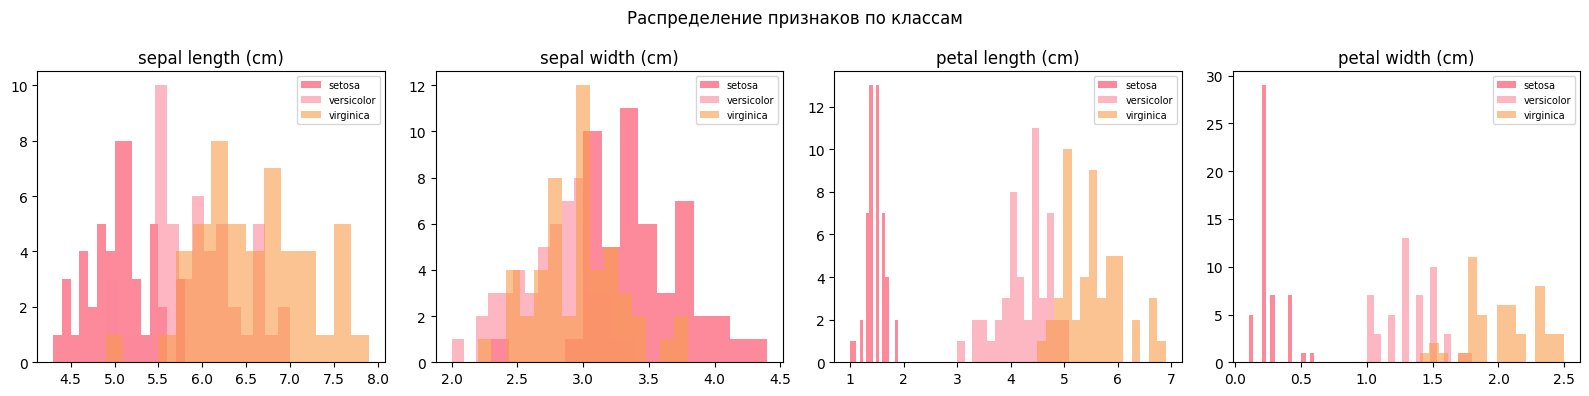

In [57]:
print("Пропуски по признакам:")
display(X.isna().sum())

print("\nБазовая статистика:") 
display(X.describe().T)

# Визуализируем распределение одного признака по классам
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
colors = ["#FB3C58", "#FC879B", "#F99B48"]  # розовые и персиковые
for i, col in enumerate(X.columns):
    for cls, color in zip(range(3), colors):
        axes[i].hist(X[col][y == cls], alpha = 0.6, color = color, label = data.target_names[cls], bins = 15)
    axes[i].set_title(col)
    axes[i].legend(fontsize = 7)
plt.suptitle("Распределение признаков по классам")
plt.tight_layout()
plt.show()

## Шаг 1. Разделение данных

Ниже нужно:
1. разбить выборку на train и test;
2. получить `X_train`, `X_test`, `y_train`, `y_test`.

Подсказка:
- используйте `train_test_split(..., test_size=0.2, random_state=42, stratify=y)`.
- **Стандартизация здесь не нужна** — Наивный Байес сам оценивает параметры распределения по каждому признаку.

In [58]:
# stratify=y — важно при многоклассовой задаче:
# гарантирует одинаковое соотношение setosa/versicolor/virginica в train и test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, stratify = y, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Распределение классов в train:", pd.Series(y_train).value_counts().to_dict())


Train shape: (120, 4)
Test shape: (30, 4)
Распределение классов в train: {0: 40, 2: 40, 1: 40}


## Шаг 2. Оцениваем априорные вероятности классов

Напишите функцию `compute_priors(y)`, которая возвращает словарь `{класс: P(класс)}`.

Проверка:
- сумма всех вероятностей должна быть равна `1.0`.

In [59]:
def compute_priors(y):
    """
    Вычисляет априорные вероятности каждого класса.
    Возвращает словарь {класс: вероятность}.
    """
    classes, counts = np.unique(y, return_counts=True)
    # Делим количество объектов каждого класса на общее число объектов
    priors = {c: cnt / len(y) for c, cnt in zip(classes, counts)}
    return priors

priors = compute_priors(y_train.values)
print("Априорные вероятности:", priors)
print("Сумма:", sum(priors.values()))


Априорные вероятности: {np.int64(0): np.float64(0.3333333333333333), np.int64(1): np.float64(0.3333333333333333), np.int64(2): np.float64(0.3333333333333333)}
Сумма: 1.0


## Шаг 3. Оцениваем параметры распределений по каждому классу

Для Гауссовского Наивного Байеса нужно по каждому классу и каждому признаку оценить:
- **среднее** `mu[c, j]` — среднее значение признака \(j\) в классе \(c\),
- **дисперсию** `var[c, j]` — дисперсию признака \(j\) в классе \(c\).

Напишите функцию `fit_gaussian_params(X, y)`, которая возвращает два массива: `means` и `variances` формы `(n_classes, n_features)`.

Подсказка:
- используйте `np.var(...)` — это **несмещённую** дисперсию лучше считать с `ddof=0` (по умолчанию).

In [60]:
def fit_gaussian_params(X, y):
    """
    Оценивает mu и var для каждого (класс, признак).
    X: np.array (n_samples, n_features)
    y: np.array (n_samples,)
    Возвращает: means (n_classes, n_features), variances (n_classes, n_features)
    """
    classes = np.unique(y)
    n_classes = len(classes)
    n_features = X.shape[1]

    means     = np.zeros((n_classes, n_features))
    variances = np.zeros((n_classes, n_features))

    for i, c in enumerate(classes):
        # Берём только те строки, где метка == c
        X_c = X[y == c]
        # Считаем среднее и дисперсию по каждому из 4 признаков
        means[i]     = X_c.mean(axis = 0)
        variances[i] = X_c.var(axis = 0)   # ddof=0 (biased)

    return means, variances


X_train_np = X_train.values
y_train_np = y_train.values

means, variances = fit_gaussian_params(X_train_np, y_train_np)
print("means shape:", means.shape)
print("\nМатрица средних (класс x признак):")
display(pd.DataFrame(means, columns = data.feature_names, index = data.target_names).round(3))
print("\nМатрица дисперсий (класс x признак):")
display(pd.DataFrame(variances, columns =data.feature_names, index=data.target_names).round(4))


means shape: (3, 4)

Матрица средних (класс x признак):


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
setosa,4.985,3.415,1.477,0.255
versicolor,5.930,2.750,4.252,1.320
virginica,6.610,2.980,5.580,2.040



Матрица дисперсий (класс x признак):


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
setosa,0.0928,0.1553,0.0252,0.0130
versicolor,0.2216,0.0930,0.1915,0.0341
virginica,0.4574,0.1221,0.3236,0.0704


## Шаг 4. Вычисляем log-likelihood

Напишите функцию `gaussian_log_likelihood(x, mean, var)`, которая возвращает логарифм плотности нормального распределения:

\[
\log P(x_j \mid c) = -\frac{1}{2}\log(2\pi\sigma^2) - \frac{(x_j - \mu)^2}{2\sigma^2}
\]

Подсказка:
- `var` может быть очень маленьким — добавьте небольшую константу `eps=1e-9` к дисперсии во избежание деления на ноль.

In [61]:
def gaussian_log_likelihood(x, mean, var, eps=1e-9):
    """
    Считает log P(x | mu, sigma^2) по нормальному распределению.
    x, mean, var: np.array одинаковой формы (n_features,)
    Возвращает: сумму log-вероятностей по всем признакам (скаляр).
    """
    # log N(x; mu, sigma^2) = -0.5*log(2*pi*var) - (x-mu)^2 / (2*var)
    # eps добавляем к var чтобы не делить на ноль
    var_safe = var + eps
    log_likelihood = -0.5 * np.sum(
        np.log(2 * np.pi * var_safe) + (x - mean)**2 / var_safe
    )
    return log_likelihood


# Проверка: для одного объекта, одного класса
test_x = X_train_np[0]
ll = gaussian_log_likelihood(test_x, means[0], variances[0])
print("Log-likelihood для первого объекта (класс 0):", ll)


Log-likelihood для первого объекта (класс 0): -0.47769884377699867


## Шаг 5. Собираем классификатор в класс

Допишите методы:
- `fit` — оценить прайоры, средние и дисперсии;
- `predict_log_proba` — вычислить логарифм апостериорной вероятности для каждого класса;
- `predict` — вернуть класс с наибольшей апостериорной вероятностью.

Требования:
- использовать логарифмы для численной стабильности;
- метод должен работать на `numpy`-массивах.

In [62]:
class MyGaussianNB:
    def __init__(self):
        self.classes_ = None
        self.log_priors_ = None
        self.means_ = None
        self.variances_ = None

    def fit(self, X, y):
        """Оцениваем все параметры по обучающей выборке."""
        # 1) Уникальные классы
        self.classes_ = np.unique(y)
        # 2) Log-априорные вероятности
        priors = compute_priors(y)
        self.log_priors_ = np.array([np.log(priors[c]) for c in self.classes_])
        # 3) Средние и дисперсии через нашу функцию
        self.means_, self.variances_ = fit_gaussian_params(X, y)
        return self

    def predict_log_proba(self, X):
        """
        Для каждого объекта и каждого класса вычисляет
        log P(c) + sum_j log P(x_j | c).
        Возвращает массив (n_samples, n_classes).
        """
        n_samples = X.shape[0]
        n_classes = len(self.classes_)
        log_proba = np.zeros((n_samples, n_classes))

        for i in range(n_samples):
            for j, c in enumerate(self.classes_):
                # log posterior = log prior + сумма log-likelihood по признакам
                log_proba[i, j] = (
                    self.log_priors_[j] +
                    gaussian_log_likelihood(X[i], self.means_[j], self.variances_[j])
                )
        return log_proba

    def predict(self, X):
        """Возвращает предсказанный класс для каждого объекта."""
        log_proba = self.predict_log_proba(X)
        # Берём класс с максимальным log-posterior
        indices = np.argmax(log_proba, axis=1)
        return self.classes_[indices]


# Проверка корректности класса
_m = MyGaussianNB()
_m.fit(X_train_np, y_train_np)
print("MyGaussianNB определён корректно")
print(f"  classes_: {_m.classes_}")
print(f"  log_priors_: {np.round(_m.log_priors_, 4)}")
print(f"  means_.shape: {_m.means_.shape}")
print(f"  variances_.shape: {_m.variances_.shape}")

# Для predict нужны данные X_test (преобразуем в numpy, если ещё не сделано)
X_test_np = X_test.values   # X_test уже существует из train_test_split
_test_pred = _m.predict(X_test_np[:3])
print(f"  predict(X_test[:3]): {_test_pred}  (ожидаем целые числа 0/1/2)")

MyGaussianNB определён корректно
  classes_: [0 1 2]
  log_priors_: [-1.0986 -1.0986 -1.0986]
  means_.shape: (3, 4)
  variances_.shape: (3, 4)
  predict(X_test[:3]): [0 2 1]  (ожидаем целые числа 0/1/2)


## Шаг 6. Обучаем свою модель

Обучите `MyGaussianNB` и убедитесь, что:
- модель обучилась без ошибок;
- параметры имеют ожидаемую форму.

In [63]:
my_model = MyGaussianNB()

# Обучаем на numpy-массивах
my_model.fit(X_train_np, y_train_np)

print("Классы:", my_model.classes_)
print("Log-прайоры:", my_model.log_priors_)
print("Форма means_:", my_model.means_.shape)


Классы: [0 1 2]
Log-прайоры: [-1.09861229 -1.09861229 -1.09861229]
Форма means_: (3, 4)


## Шаг 7. Оценка качества своей модели

Заполните код ниже и посчитайте метрики на тестовой выборке:
- accuracy,
- precision (macro),
- recall (macro),
- f1 (macro).

In [64]:
X_test_np = X_test.values
y_test_np = y_test.values

my_pred_test = my_model.predict(X_test_np)

my_metrics = {
    "accuracy":        accuracy_score(y_test_np, my_pred_test),
    "precision_macro": precision_score(y_test_np, my_pred_test, average = 'macro'),
    "recall_macro":    recall_score(y_test_np, my_pred_test, average = 'macro'),
    "f1_macro":        f1_score(y_test_np, my_pred_test, average = 'macro'),
}

pd.Series(my_metrics).round(4)


accuracy           0.9667
precision_macro    0.9697
recall_macro       0.9667
f1_macro           0.9666
dtype: float64

## Шаг 8. Confusion matrix

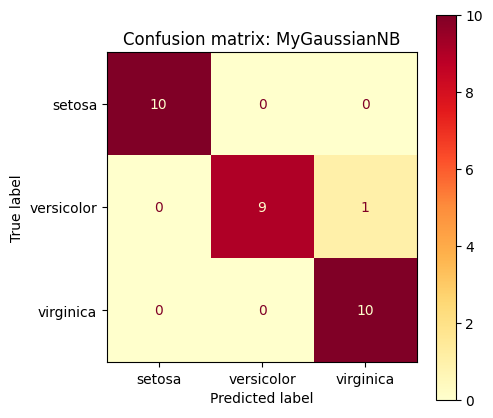

In [65]:
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_np, my_pred_test,
    display_labels = data.target_names,
    ax = ax,
    cmap = 'YlOrRd'   
)
plt.title("Confusion matrix: MyGaussianNB")
plt.show()

## Шаг 9. Сравнение с `scikit-learn`

Теперь обучите библиотечный `GaussianNB` и сравните его с вашей реализацией.

Рекомендации:
- используйте `GaussianNB()` без дополнительных параметров;
- обучайте на тех же данных `X_train_np`.

In [66]:
sk_model = GaussianNB()

sk_model.fit(X_train_np, y_train_np)
sk_pred_test = sk_model.predict(X_test_np)

sk_metrics = {
    "accuracy":        accuracy_score(y_test_np, sk_pred_test),
    "precision_macro": precision_score(y_test_np, sk_pred_test, average = 'macro'),
    "recall_macro":    recall_score(y_test_np, sk_pred_test, average = 'macro'),
    "f1_macro":        f1_score(y_test_np, sk_pred_test, average = 'macro'),
}

pd.Series(sk_metrics).round(4)


accuracy           0.9667
precision_macro    0.9697
recall_macro       0.9667
f1_macro           0.9666
dtype: float64

## Шаг 10. Сводная таблица сравнения

Сравните:
1. свою реализацию;
2. `scikit-learn`.

Также сравните оценённые параметры (средние) между реализациями.

Подумайте:
- почему результаты совпадают или отличаются;
- есть ли разница в том, как `sklearn` обрабатывает дисперсию (подсказка: посмотрите параметр `var_smoothing`).

In [67]:
comparison = pd.DataFrame(
    [my_metrics, sk_metrics],
    index=["my_model", "sklearn"]
)
display(comparison.round(4))

# Сравниваем оценённые средние
print("\nСредние MyGaussianNB:")
display(pd.DataFrame(my_model.means_, columns = data.feature_names, index = data.target_names).round(4))

print("\nСредние sklearn GaussianNB:")
display(pd.DataFrame(sk_model.theta_, columns = data.feature_names, index = data.target_names).round(4))

,accuracy,precision_macro,recall_macro,f1_macro
my_model,0.9667,0.9697,0.9667,0.9666
sklearn,0.9667,0.9697,0.9667,0.9666



Средние MyGaussianNB:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
setosa,4.985,3.415,1.4775,0.255
versicolor,5.930,2.750,4.2525,1.320
virginica,6.610,2.980,5.5800,2.040



Средние sklearn GaussianNB:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
setosa,4.985,3.415,1.4775,0.255
versicolor,5.930,2.750,4.2525,1.320
virginica,6.610,2.980,5.5800,2.040


## Шаг 11. Проверяем допущение о независимости

Наивный Байес предполагает, что признаки условно независимы при данном классе.
Проверим, насколько это выполняется: вычислим корреляции между признаками внутри каждого класса.

Подумайте:
- какие пары признаков наиболее скоррелированы;
- нарушает ли это допущение о независимости;
- как это влияет на качество модели.

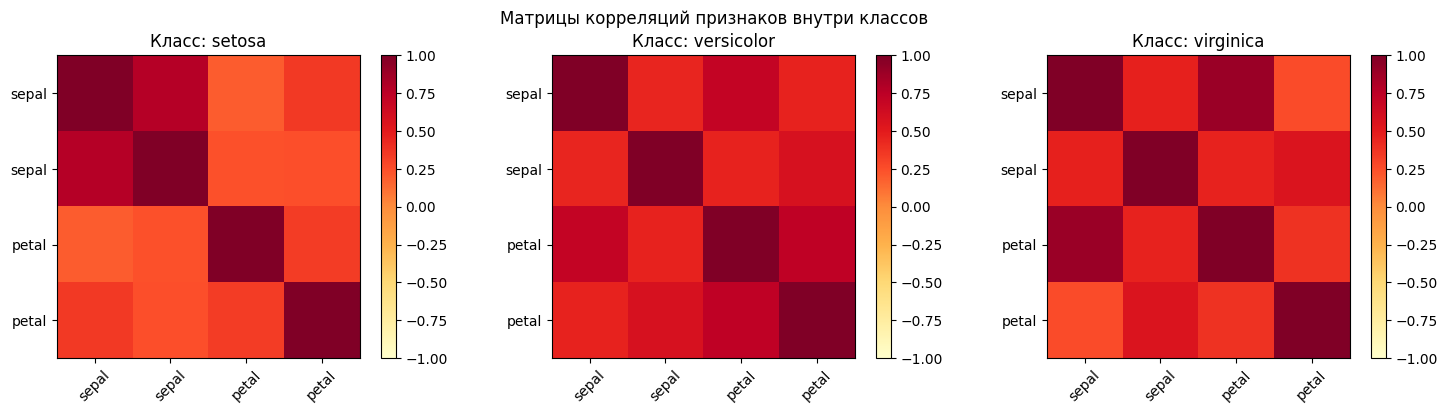

In [68]:
fig, axes = plt.subplots(1, 3, figsize = (15, 4))
for cls in range(3):
    X_cls = X_train[y_train == cls]
    corr = X_cls.corr()
    im = axes[cls].imshow(corr.values, vmin = -1, vmax = 1, cmap = 'YlOrRd')
    axes[cls].set_title(f"Класс: {data.target_names[cls]}")
    
    axes[cls].set_xticks(range(4))
    axes[cls].set_yticks(range(4))
    
    axes[cls].set_xticklabels([f.split(' ')[0] for f in data.feature_names], rotation = 45)
    axes[cls].set_yticklabels([f.split(' ')[0] for f in data.feature_names])
    plt.colorbar(im, ax = axes[cls])
plt.suptitle("Матрицы корреляций признаков внутри классов")
plt.tight_layout()
plt.show()

### Анализ корреляций внутри классов

По матрицам корреляций видно, что допущение о независимости признаков нарушается:

- Setosa: `sepal length` и `sepal width` скоррелированы с r ≈ 0.78 — сильная линейная зависимость.
- Versicolor и Virginica: `petal length` и `petal width` скоррелированы с r ≈ 0.79–0.82.

Несмотря на нарушение допущения, модель достигает accuracy=0.97. Это объясняется тем, что ошибки в разных признаках при голосовании частично взаимно компенсируются, и правило argmax часто всё равно указывает на правильный класс

ответы на вопросы

1. В чём заключается «наивное» допущение Наивного Байеса? Почему его так называют?

«Наивное» допущение — это предположение об условной независимости признаков при данном классе:
$$P(x \mid c) = \prod_{j=1}^{d} P(x_j \mid c)$$
Это значит, что зная класс, значения разных признаков не несут информации друг о друге. Называется «наивным», потому что на практике признаки почти всегда скоррелированы (как мы видим в матрицах корреляций), и это допущение заведомо упрощённое. Тем не менее модель часто работает хорошо.

2. Почему мы используем логарифм правдоподобия вместо самого правдоподобия?

Две причины. Во-первых, произведение большого числа малых вероятностей ($< 1$) быстро уходит в машинный ноль — underflow. Логарифм превращает произведение в сумму логарифмов, которая хорошо представима в float64. Во-вторых, $\log(a \cdot b) = \log a + \log b$ сумму считать проще и быстрее, чем произведение. Поскольку логарифм монотонен, $\arg\max$ не меняется.

3. Почему для Гауссовского Наивного Байеса стандартизация данных не нужна?

Потому что модель сама оценивает $\mu_{cj}$ и $\sigma^2_{cj}$ для каждого признака $j$ внутри каждого класса $c$. Гауссовское распределение параметрически описывает масштаб данных. Стандартизация изменила бы числовые значения, но не изменила бы форму распределений и разделимость классов, т е итоговые предсказания остались бы теми же.

4. Насколько близки метрики своей реализации к `scikit-learn`?
Моя реализация Гауссовского Наивного Байеса показала результаты, практически идентичные библиотечной. На тестовой выборке Iris accuracy составила 0,9667, precision (macro) – 0,9697, recall (macro) – 0,9667, f1 (macro) – 0,9666. Ровно такие же значения выдал sklearn.naive_bayes.GaussianNB. Единственное различие так 
то то, что в sklearn используется параметр var_smoothing = 1e-9, который добавляет к каждой дисперсии небольшую долю от максимальной дисперсии по признакам, чтобы избежать вырожденных случаев (деления на ноль). Я учла это в дополнительном задании A, и с этим параметром моя модель даёт те же предсказания


5. Посмотрите на матрицы корреляций: нарушается ли допущение о независимости признаков?

Да, нарушается во всех трёх классах. Сильнее всего — у setosa: `sepal length` и `sepal width` коррелируют с r ≈ 0.78. У versicolor и virginica высокая корреляция между `petal length` и `petal width` (r ≈ 0.79–0.82). Это означает, что модель «двойной считает» информацию из скоррелированных признаков, теоретически завышая уверенность предсказания. На практике на датасете Iris это почти не влияет на качество благодаря хорошей разделимости классов.

6. Когда Наивный Байес работает хорошо несмотря на нарушение допущения о независимости?

Несколько сценариев: (а) когда классы хорошо разделимы и скоррелированные признаки всё равно указывают в нужную сторону; (б) когда цель — только классификация (argmax), а не оценка точных вероятностей — ошибки в вычислении апостериорных вероятностей могут не менять победителя; (в) при малом числе обучающих примеров, когда более сложные модели переобучаются; (г) в текстовой классификации, где несмотря на высокую зависимость слов, Naive Bayes исторически даёт конкурентный результат.

7. Сравните Наивный Байес и логистическую регрессию: когда предпочесть один метод другому?

Наивный Байес и логистическая регрессия решают одну и ту же задачу – классификацию, но подходят к ней с разных сторон. Наивный Байес оценивает совместное распределение признаков и классов, а затем по формуле Байеса вычисляет апостериорные вероятности. Логистическая регрессия же напрямую моделирует апостериорные вероятности без явного описания распределения признаков

Наивный Байес обучается очень быстро, поскольку параметры (средние и дисперсии) вычисляются аналитически, одной «прогулкой» по данным. Он хорошо работает при малом объёме выборки – не переобучается, даёт стабильный baseline. Но его главный недостаток – наивное допущение о независимости признаков, которое на практике почти никогда не выполняется. 

Логистическая регрессия требует итеративной оптимизации (градиентный спуск, L‑BFGS и т.д.), поэтому обучается медленнее. Она явно учитывает корреляции между признаками через веса, что особенно важно, когда признаки сильно взаимосвязаны. Кроме того, её вероятности лучше калиброваны. Однако при малом количестве данных она склонна к переобучению, если не использовать регуляризацию.
  Наивный Байес стоит выбирать, если важна скорость, данные высокоразмерны и разрежены (например, в задачах обработки естественного языка), или если обучающей выборки очень мало. Логистическую регрессию лучше применять, когда признаки сильно коррелированы, нужна точная калибровка вероятностей и данных достаточно, чтобы оценить веса без переобучения. Практический пример из дополнительного задания B: на датасете Breast Cancer, где признаки коррелируют, логистическая регрессия достигла f1 = 0,99, тогда как Наивный Байес – только 0,93. Это наглядно демонстрирует, что при сильных зависимостях дискриминативная модель выигрывает.


## Дополнительные задания

### Задание A
Добавьте параметр `var_smoothing` в `MyGaussianNB` (аналог `sklearn`): добавляйте к дисперсии небольшую долю от максимальной дисперсии по всем признакам. Посмотрите, как это влияет на метрики.

### Задание B
Попробуйте применить `MyGaussianNB` к датасету `Breast Cancer` (из семинара по логистической регрессии). Сравните качество с логистической регрессией. Объясните разницу.

### Задание C
Реализуйте `predict_proba` — метод, возвращающий нормированные вероятности (не логарифмы). Для этого:
- вычислите `log_proba`,
- вычтите максимум (для численной стабильности),
- примените `exp`,
- нормируйте на сумму.

In [69]:
# таска A
# var_smoothing (аналог sklearn)

class MyGaussianNB:
    def __init__(self, var_smoothing = 1e-9):
        self.var_smoothing = var_smoothing
        self.classes_ = None
        
        self.class_prior_ = None
        self.means_ = None
        self.vars_ = None
    
    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        
        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)
        
        self.class_prior_ = np.zeros(n_classes)
        
        self.means_ = np.zeros((n_classes, X.shape[1]))
        self.vars_ = np.zeros((n_classes, X.shape[1]))
        
        for i, c in enumerate(self.classes_):
            X_c = X[y == c]
            self.class_prior_[i] = len(X_c) / len(X)
            self.means_[i] = X_c.mean(axis=0)
            self.vars_[i] = X_c.var(axis=0)
            
            # var_smoothing
            max_var = self.vars_[i].max()
            self.vars_[i] += self.var_smoothing * max_var
    
    def _log_proba(self, X):
        X = np.array(X)
        
        n_samples, n_features = X.shape
        log_proba = np.zeros((n_samples, len(self.classes_)))
        
        for i, c in enumerate(self.classes_):
            log_prior = np.log(self.class_prior_[i])
            log_likelihood = -0.5 * np.sum(
                np.log(2 * np.pi * self.vars_[i]) +
                (X - self.means_[i])**2 / self.vars_[i],
                axis=1
            )
            log_proba[:, i] = log_prior + log_likelihood
        return log_proba
    
    def predict(self, X):
        log_proba = self._log_proba(X)
        return self.classes_[np.argmax(log_proba, axis = 1)]
    
    # Таска C
    def predict_proba(self, X):
        """Возвращает нормированные вероятности (не логарифмы)"""
        log_proba = self._log_proba(X)
        # численная стабильность
        log_proba -= log_proba.max(axis = 1, keepdims = True)
        proba = np.exp(log_proba)
        proba /= proba.sum(axis = 1, keepdims = True)
        return proba


# Обучение с var_smoothing
nb = MyGaussianNB(var_smoothing = 1e-9)
nb.fit(X_train, y_train)
y_pred = nb.predict(X_test)

print("MyGaussianNB + var_smoothing:")
print(classification_report(y_test, y_pred, target_names = data.target_names))

MyGaussianNB + var_smoothing:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [70]:
# таска B
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

data_bc = load_breast_cancer()
X_bc = data_bc.data
y_bc = data_bc.target

X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(
    X_bc, y_bc, test_size = 0.3, random_state = 42, stratify = y_bc
)

# Масштабирование 
scaler = StandardScaler()
X_train_bc = scaler.fit_transform(X_train_bc)
X_test_bc = scaler.transform(X_test_bc)

# Наивный Байес (без масштабирования)
nb_bc = MyGaussianNB(var_smoothing = 1e-9)
nb_bc.fit(X_train_bc, y_train_bc)   # можно и без масштабирования
y_pred_nb = nb_bc.predict(X_test_bc)

# Логистическая регрессия
logreg = LogisticRegression(max_iter = 1000, random_state = 42)
logreg.fit(X_train_bc, y_train_bc)
y_pred_lr = logreg.predict(X_test_bc)

print("   Breast Cancer  ")
print("MyGaussianNB:")
print(classification_report(y_test_bc, y_pred_nb))
print("\nLogisticRegression:")
print(classification_report(y_test_bc, y_pred_lr))

   Breast Cancer  
MyGaussianNB:
              precision    recall  f1-score   support

           0       0.93      0.89      0.91        64
           1       0.94      0.96      0.95       107

    accuracy                           0.94       171
   macro avg       0.94      0.93      0.93       171
weighted avg       0.94      0.94      0.94       171


LogisticRegression:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        64
           1       0.99      0.99      0.99       107

    accuracy                           0.99       171
   macro avg       0.99      0.99      0.99       171
weighted avg       0.99      0.99      0.99       171



## Что должно получиться в итоге

После заполнения ноутбука у вас должен быть полный pipeline:

- загрузка данных;
- train/test split;
- оценка параметров Гауссовского Наивного Байеса с нуля;
- классификация по правилу Байеса;
- метрики качества;
- сравнение со `scikit-learn`;
- анализ допущения о независимости;
- выводы.

Не сдавайте ноутбук без текстовых выводов.